<div style="
    background: linear-gradient(135deg, #f8fafc, #e2e8f0);
    padding: 20px;
    border-radius: 100px;
    text-align: center;
    font-family: 'Segoe UI', Tahoma;
    box-shadow: 0 4px 12px rgba(3,6,9,12.15);
">
    <h1 style="
        color: #1e3a8a;
        margin-bottom: 30px;
        font-weight: bold;
    ">
         "Credit Card Fraud Detection"
    </h1>
    
<h2 style="
        color: #1e3a8a;
        margin-bottom: 10px;
        font-weight: bold;
    ">
        Task: Binary Classification (Fraud vs Non-Fraud)
    </h2>     

</div>

# =========================
# Import Libraries
# =========================

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
# Visualization tools
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")

# ===============================
# Exploratory Data Analysis (EDA) and Visualization
# ===============================

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [5]:
df.sample(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
249197,154291.0,1.421963,-1.353347,-1.219614,0.074948,0.318924,1.881687,-0.449603,0.548561,0.902411,...,-0.207542,-0.969058,0.295044,-0.965302,-0.866657,0.201923,-0.051593,-0.026064,250.77,0
113005,72891.0,1.237814,0.274817,0.183680,0.502780,-0.180946,-0.568218,-0.045547,-0.017674,-0.157114,...,-0.261580,-0.803178,0.080789,-0.045557,0.219485,0.098449,-0.029221,0.016503,0.99,0
62649,50358.0,-0.977687,0.296686,2.720433,-0.343553,0.065381,-0.268315,0.477058,0.055891,0.102415,...,0.261982,0.820420,-0.217279,0.541279,0.150477,-0.626173,-0.072368,-0.105023,35.72,0
92849,64135.0,-0.797407,1.481331,1.086232,-0.048858,-0.040438,-1.011496,0.708287,-0.063677,-0.045277,...,-0.323151,-0.715025,0.019483,0.326018,-0.045923,0.081186,0.457528,0.223918,3.59,0
141252,84202.0,-1.683370,1.848419,-0.080016,-0.131855,-0.783122,-0.665325,-0.219380,1.269169,-0.996234,...,-0.251953,-1.225900,0.335760,-0.080546,-0.698217,-0.232980,-0.281475,-0.019757,25.15,0
43002,41332.0,-0.887765,1.416356,0.114749,0.850722,1.006463,0.878869,0.331757,0.838715,-0.891424,...,0.169194,0.653100,0.033921,-1.045675,-0.473393,-0.223666,0.370940,0.160754,15.27,0
102505,68231.0,1.184877,-0.618750,1.365225,0.469114,-1.107904,0.765040,-1.072670,0.256539,1.773485,...,-0.151002,0.096296,-0.165337,-0.290405,0.414440,1.175826,0.010706,0.014349,22.26,0
70749,54001.0,1.438894,-1.063113,-0.484970,-1.683551,-0.626655,-0.259889,-0.509327,-0.187760,-2.412032,...,-0.505813,-1.301899,-0.050406,-0.877087,0.409666,-0.436809,-0.011004,0.009001,88.49,0
256097,157537.0,1.963128,-0.002556,-1.895572,0.208714,1.091339,0.680628,-0.064528,0.206099,0.520003,...,-0.299468,-0.655779,0.399931,-0.660458,-0.448942,0.277501,-0.013980,-0.043678,1.29,0
234454,147980.0,-0.890002,0.610821,-0.629999,-0.523862,0.495338,-0.791860,0.536095,0.483533,0.344935,...,-0.168540,-0.678152,0.074564,0.507812,0.280299,-0.091448,0.080278,-0.047851,80.05,0


In [6]:
df.shape

(284807, 31)

In [7]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [8]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

# Missing Values

In [10]:
print(" Null Values:")
print(df.isnull().sum())

 Null Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


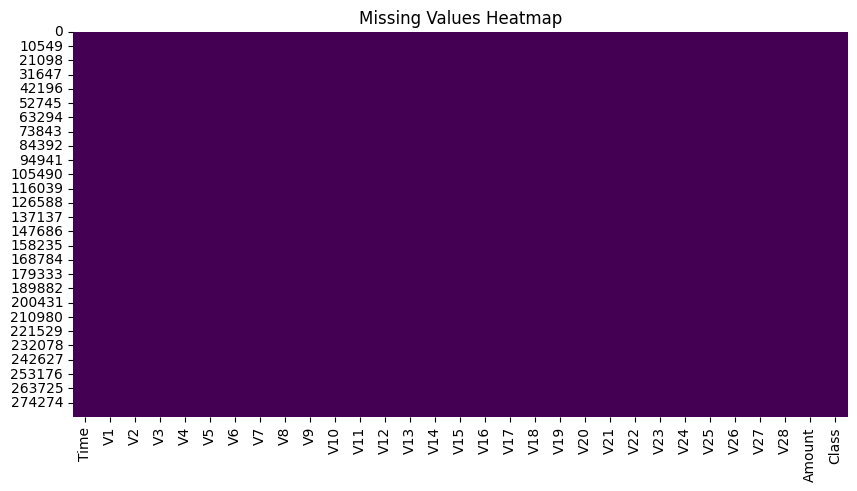

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# Data Types

In [12]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

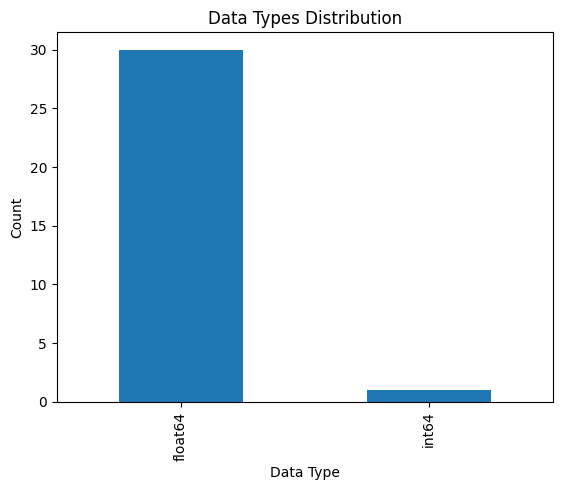

In [13]:
df.dtypes.value_counts().plot(kind='bar')
plt.title("Data Types Distribution")
plt.xlabel("Data Type")
plt.ylabel("Count")
plt.show()

# Distribution of Class (Target)

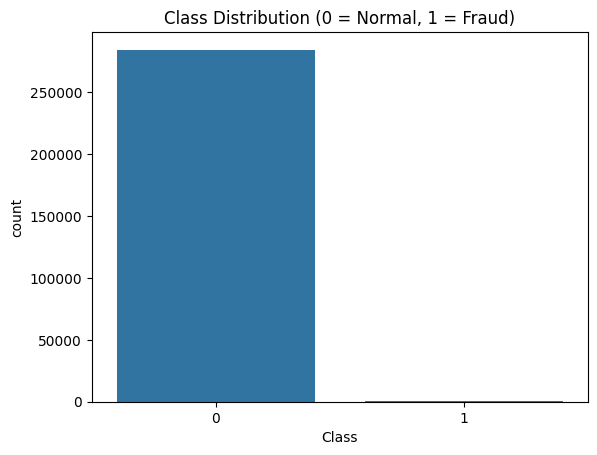

In [14]:
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.show()

# Distribution of Amount

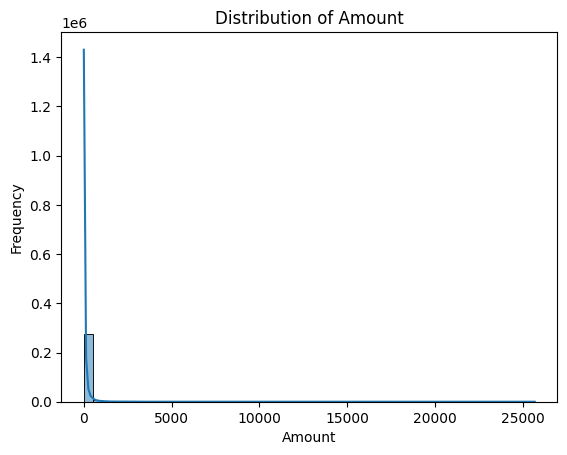

In [15]:
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title("Distribution of Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# Distribution of Time

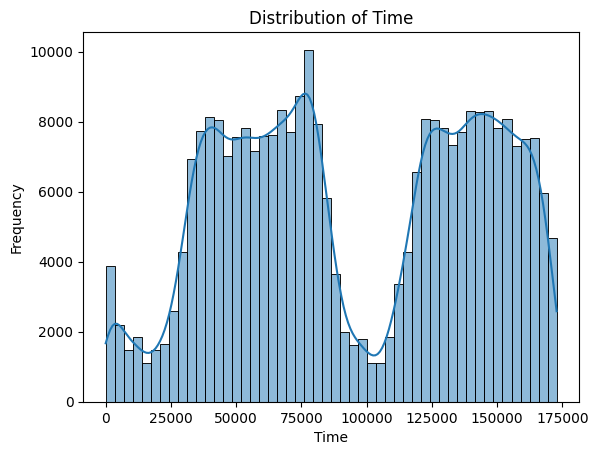

In [16]:
sns.histplot(df['Time'], bins=50, kde=True)
plt.title("Distribution of Time")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

# outliers

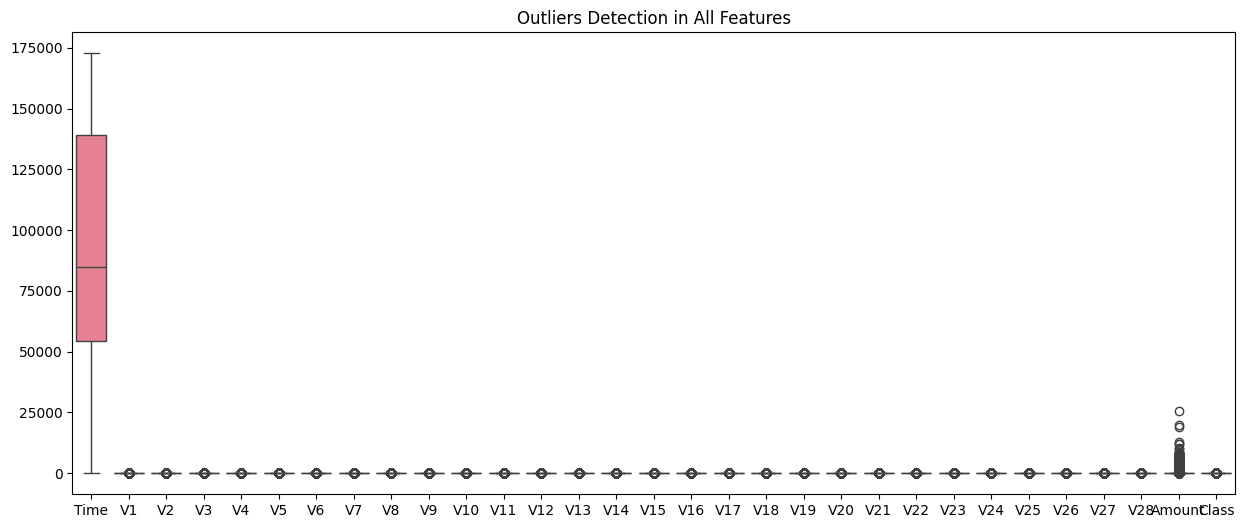

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
sns.boxplot(data=df)
plt.title("Outliers Detection in All Features")
plt.show()

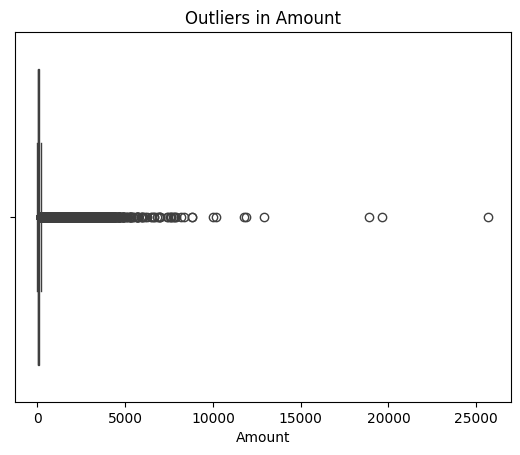

In [18]:
sns.boxplot(x=df['Amount'])
plt.title("Outliers in Amount")
plt.show()

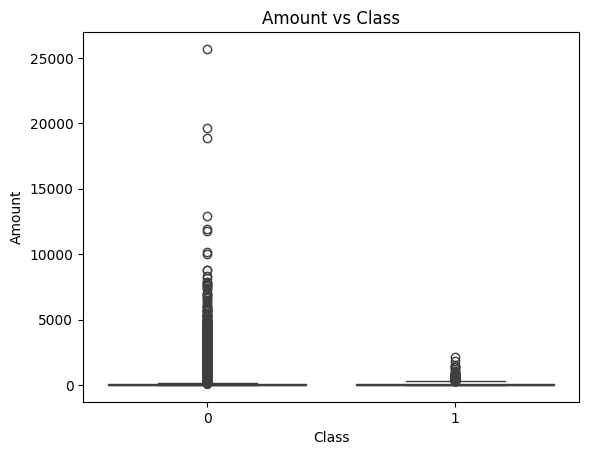

In [19]:
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Amount vs Class")
plt.show()


# Correlation Heatmap

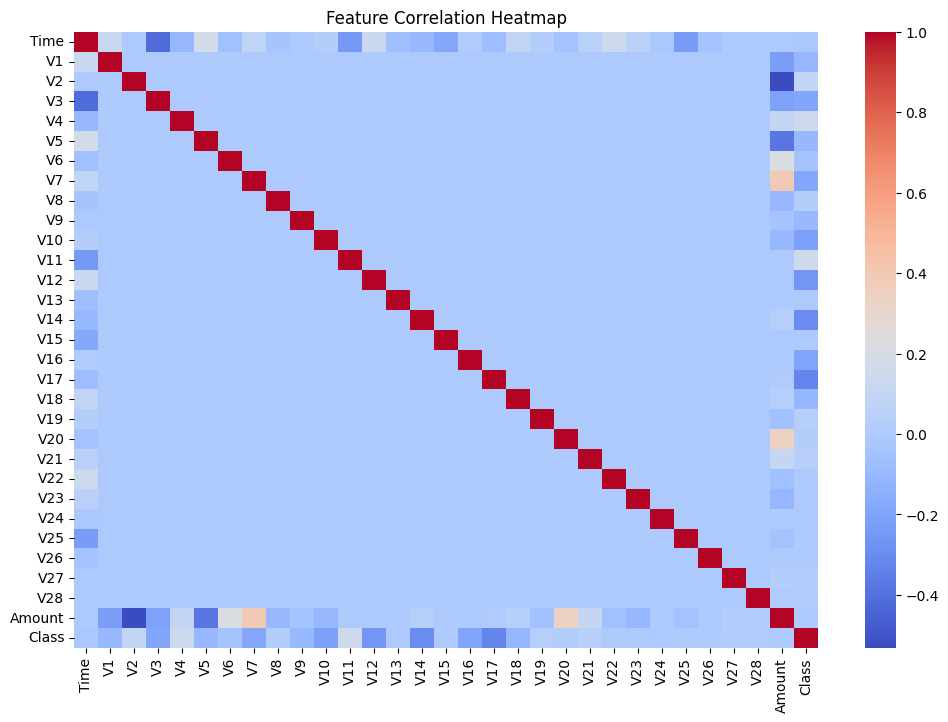

In [20]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [21]:
for col in df.columns:
    print(f"{col} - unique values: {df[col].nunique()}")

Time - unique values: 124592
V1 - unique values: 275663
V2 - unique values: 275663
V3 - unique values: 275663
V4 - unique values: 275663
V5 - unique values: 275663
V6 - unique values: 275663
V7 - unique values: 275663
V8 - unique values: 275663
V9 - unique values: 275663
V10 - unique values: 275663
V11 - unique values: 275663
V12 - unique values: 275663
V13 - unique values: 275663
V14 - unique values: 275663
V15 - unique values: 275663
V16 - unique values: 275663
V17 - unique values: 275663
V18 - unique values: 275663
V19 - unique values: 275663
V20 - unique values: 275663
V21 - unique values: 275663
V22 - unique values: 275663
V23 - unique values: 275663
V24 - unique values: 275663
V25 - unique values: 275663
V26 - unique values: 275663
V27 - unique values: 275663
V28 - unique values: 275663
Amount - unique values: 32767
Class - unique values: 2


# The dataset suffers from severe class imbalance, where fraud cases are very few compared to normal transactions.
# To avoid data leakage, the imbalance was handled after the train-test split using SMOTE on the training data only.

In [22]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [23]:
df['Class'].value_counts('Nor')*100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

# ===============================
# Preprocessing + Data Cleaning
# ===============================

In [24]:
df.duplicated().sum()

np.int64(1081)

In [25]:
df = df.drop_duplicates()

In [26]:
df.duplicated().sum()
df[df.duplicated()].sum()

Time      0.0
V1        0.0
V2        0.0
V3        0.0
V4        0.0
V5        0.0
V6        0.0
V7        0.0
V8        0.0
V9        0.0
V10       0.0
V11       0.0
V12       0.0
V13       0.0
V14       0.0
V15       0.0
V16       0.0
V17       0.0
V18       0.0
V19       0.0
V20       0.0
V21       0.0
V22       0.0
V23       0.0
V24       0.0
V25       0.0
V26       0.0
V27       0.0
V28       0.0
Amount    0.0
Class     0.0
dtype: float64

# Handling outliers in the 'Amount' feature using log transformation to reduce the impact of extreme values

In [27]:
import numpy as np

df['Amount'] = np.log1p(df['Amount'])

# ===============================
# Feature Engineering
# ===============================

In [28]:
df['Hour'] = (df['Time'] // 3600) % 24


# ===============================
# (Train/Test Split)
# ===============================

# Splitting Data into Features and Target Variable

In [29]:
X = df.drop('Class', axis=1)
y = df['Class']

# Splitting Data into Training and Testing Sets

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3, random_state=42)

# Scaling (Standardization)

In [31]:
from sklearn.preprocessing import StandardScaler

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
X.shape[0] == y.shape[0]

True

In [35]:
print(X_train_scaled.shape)
print(y_train.shape)

(198608, 31)
(198608,)


# SMOTE

In [36]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

In [37]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [38]:
X_train_resampled.shape , y_train_resampled.value_counts()

((396538, 31),
 Class
 0    198269
 1    198269
 Name: count, dtype: int64)

# ===============================
# Modeling + Evaluation
# ===============================

# LogisticRegression

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
log_reg = LogisticRegression()
log_reg.fit(X_train_resampled, y_train_resampled)

y_pred = log_reg.predict(X_test_scaled)


print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
print("Accuracy:", accuracy_score(y_test, y_pred))

Confusion Matrix:
 [[82879  2105]
 [   16   118]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9998    0.9752    0.9874     84984
           1     0.0531    0.8806    0.1001       134

    accuracy                         0.9751     85118
   macro avg     0.5264    0.9279    0.5437     85118
weighted avg     0.9983    0.9751    0.9860     85118

Accuracy: 0.9750816513545901


# xgboost

In [40]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [41]:
from xgboost import XGBClassifier

In [42]:
xgb_resampled = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb_resampled.fit(X_train_resampled, y_train_resampled)
y_pred_xgb_resampled = xgb_resampled.predict(X_test_scaled)

print("Confusion Matrix (XGBoost - Resampled):")
print(confusion_matrix(y_test, y_pred_xgb_resampled))
print(classification_report(y_test, y_pred_xgb_resampled))
print("Accuracy:", accuracy_score(y_test, y_pred))

Confusion Matrix (XGBoost - Resampled):
[[84847   137]
 [   23   111]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84984
           1       0.45      0.83      0.58       134

    accuracy                           1.00     85118
   macro avg       0.72      0.91      0.79     85118
weighted avg       1.00      1.00      1.00     85118

Accuracy: 0.9750816513545901


#  DecisionTree

In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_resampled, y_train_resampled)

y_pred_dt = dt_model.predict(X_test_scaled)

print("Decision Tree Results")
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Results
[[84842   142]
 [   35    99]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84984
           1       0.41      0.74      0.53       134

    accuracy                           1.00     85118
   macro avg       0.71      0.87      0.76     85118
weighted avg       1.00      1.00      1.00     85118

Accuracy: 0.9979205338471299


# MODEL ACCURACY COMPARISON

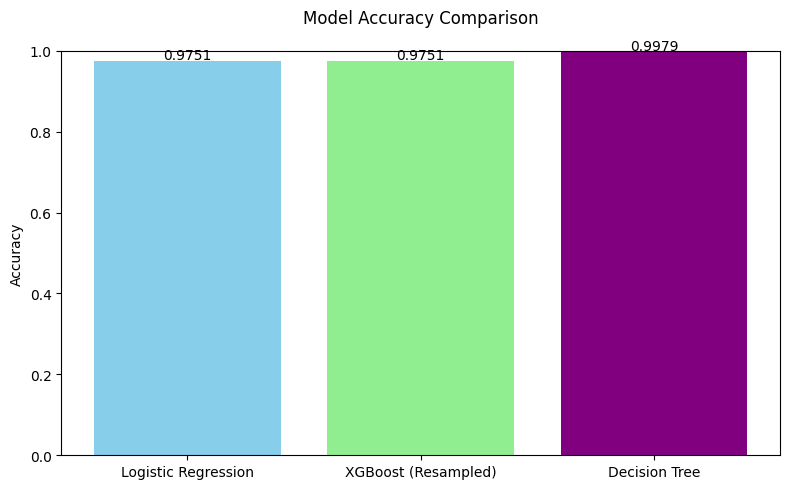

In [44]:
models = ['Logistic Regression', 'XGBoost (Resampled)', 'Decision Tree']

accuracies = [
    0.9750816513545901,
    0.9750816513545901,
    0.9979205338471299
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies, color=['skyblue', 'lightgreen', 'purple'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison', pad=20)

for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.005, f"{acc:.4f}", ha='center')

plt.tight_layout()
plt.show()

# Model Comparison based on Recall

Model Comparison:

                 Model  Precision  Recall  F1-score
0  Logistic Regression     0.0531  0.8806    0.1001
1  XGBoost (Resampled)     0.4500  0.8300    0.5800
2        Decision Tree     0.4100  0.7400    0.5300

Best Model based on Recall:
Model        Logistic Regression
Precision                 0.0531
Recall                    0.8806
F1-score                  0.1001
Name: 0, dtype: object


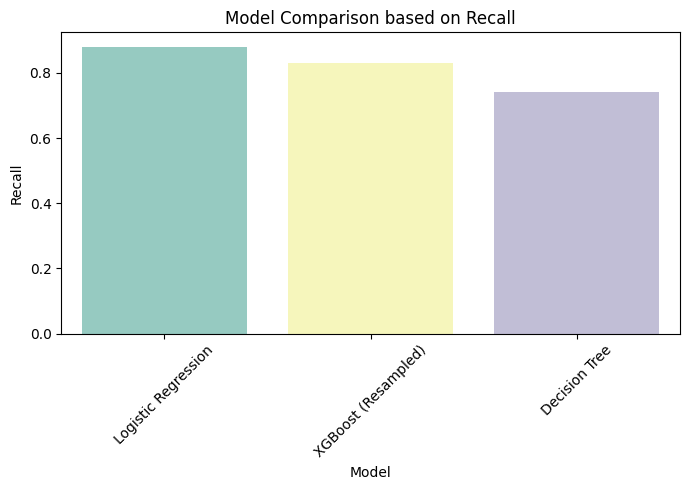

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results = [
    {'Model': 'Logistic Regression', 'Precision': 0.0531, 'Recall': 0.8806, 'F1-score': 0.1001},
    {'Model': 'XGBoost (Resampled)', 'Precision': 0.45, 'Recall': 0.83, 'F1-score': 0.58},
    {'Model': 'Decision Tree', 'Precision': 0.41, 'Recall': 0.74, 'F1-score': 0.53},
]

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by='Recall', ascending=False)

print("Model Comparison:\n")
print(results_df)

best_model = results_df.iloc[0]
print("\nBest Model based on Recall:")
print(best_model)

plt.figure(figsize=(7,5))
sns.barplot(
    x='Model',
    y='Recall',
    data=results_df,
    hue='Model',
    palette='Set3',
    legend=False
)

plt.xticks(rotation=45)
plt.title("Model Comparison based on Recall")
plt.tight_layout()
plt.show()

<div style="
    background: linear-gradient(135deg, #a78bfa, #c4b5fd);
    padding: 10px;
    border-radius: 200px;
    text-align: center;
    font-family: 'Segoe UI', Tahoma;
    box-shadow: 9 4px 12px rgba(3,6,9,12.15);
">
    <h1 style="
        color: #1e3a8a;
        margin-bottom: 30px;
        font-weight: bold;
    ">
         "📉 Dimensionality Reduction"
    </h1
</div>

# *******************************
# PCA
# *******************************

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA

# 🔹 1. Split
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 🔹 2. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🔹 3. SMOTE (بعد scaling)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled, y_train
)

X_train_resampled.shape , y_train_resampled.value_counts()


((396538, 31),
 Class
 0    198269
 1    198269
 Name: count, dtype: int64)

In [47]:
# 🔹 4. PCA (بعد SMOTE)
pca = PCA(n_components=0.95) # يحافظ على 95% من المعلومات
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [48]:
# 🔹 2. عدد الأبعاد قبل وبعد
print("Original shape:", X_train_scaled.shape)
print("After PCA shape:", X_train_pca.shape)

Original shape: (198608, 31)
After PCA shape: (198608, 28)


In [49]:
# 🔹 3. نسبة المعلومات المحفوظة
print("Explained variance ratio:", sum(pca.explained_variance_ratio_))

Explained variance ratio: 0.964018596840962


In [50]:
# 🔹 4. عدد الـ components المستخدمة
print("Number of components:", pca.n_components_)

Number of components: 28


# ===============================
# Modeling + Evaluation after PCA
# ===============================

# LogisticRegression

In [51]:
log_reg = LogisticRegression()

# training
log_reg.fit(X_train_pca, y_train)

# prediction
y_pred = log_reg.predict(X_test_pca)

# evaluation
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))
print("Accuracy:", accuracy_score(y_test, y_pred))

[[84974    10]
 [   60    74]]
              precision    recall  f1-score   support

           0     0.9993    0.9999    0.9996     84984
           1     0.8810    0.5522    0.6789       134

    accuracy                         0.9992     85118
   macro avg     0.9401    0.7761    0.8392     85118
weighted avg     0.9991    0.9992    0.9991     85118

Accuracy: 0.999177612255927


# xgboost 

In [52]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [53]:
from xgboost import XGBClassifier

In [54]:
xgb_resampled = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb_resampled.fit(X_train_pca, y_train)
y_pred_xgb_resampled = xgb_resampled.predict(X_test_pca)

print("Confusion Matrix (XGBoost - Resampled):")
print(confusion_matrix(y_test, y_pred_xgb_resampled))
print(classification_report(y_test, y_pred_xgb_resampled))
print("Accuracy:", accuracy_score(y_test, y_pred))

Confusion Matrix (XGBoost - Resampled):
[[84975     9]
 [   34   100]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84984
           1       0.92      0.75      0.82       134

    accuracy                           1.00     85118
   macro avg       0.96      0.87      0.91     85118
weighted avg       1.00      1.00      1.00     85118

Accuracy: 0.999177612255927


# DecisionTree

In [55]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_pca, y_train)

y_pred_dt = dt_model.predict(X_test_pca)

print("Decision Tree Results")
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Results
[[84961    23]
 [   45    89]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84984
           1       0.79      0.66      0.72       134

    accuracy                           1.00     85118
   macro avg       0.90      0.83      0.86     85118
weighted avg       1.00      1.00      1.00     85118

Accuracy: 0.9992011090486148


# MODEL ACCURACY COMPARISON AFTER PCA

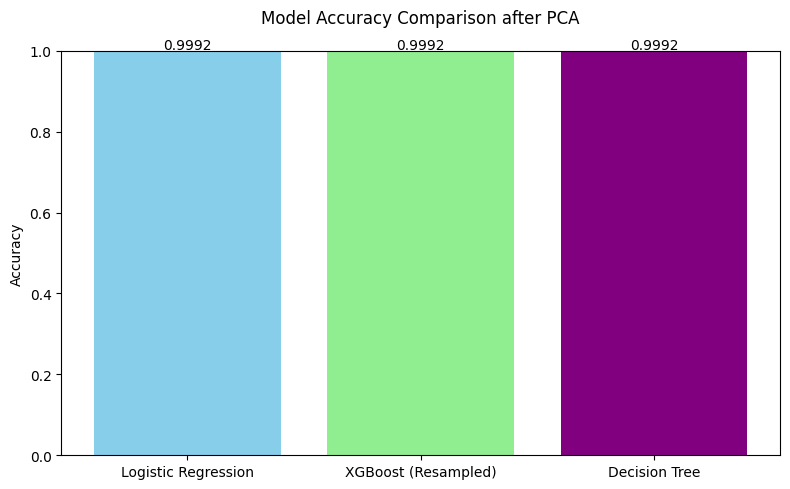

In [56]:
models = ['Logistic Regression', 'XGBoost (Resampled)', 'Decision Tree']

accuracies = [
    0.999177612255927,
    0.999177612255927,
    0.9992011090486148
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies, color=['skyblue', 'lightgreen', 'purple'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison after PCA', pad=20)

for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.005, f"{acc:.4f}", ha='center')

plt.tight_layout()
plt.show()

# Model Comparison based on Recall after PCA 

Model Comparison:

                 Model  Precision  Recall  F1-score
1  XGBoost (Resampled)      0.920  0.7500    0.8200
2        Decision Tree      0.790  0.6600    0.7200
0  Logistic Regression      0.881  0.5522    0.6789

Best Model based on Recall:
Model        XGBoost (Resampled)
Precision                   0.92
Recall                      0.75
F1-score                    0.82
Name: 1, dtype: object


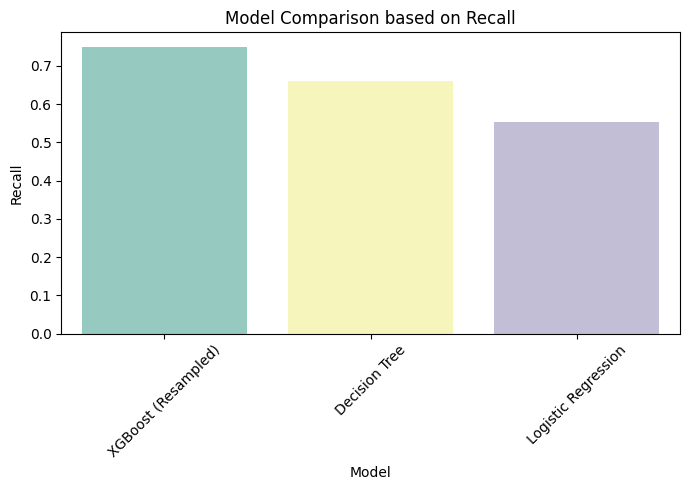

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results = [
    {'Model': 'Logistic Regression', 'Precision': 0.8810, 'Recall': 0.5522, 'F1-score': 0.6789},
    {'Model': 'XGBoost (Resampled)', 'Precision': 0.92, 'Recall': 0.75, 'F1-score': 0.82},
    {'Model': 'Decision Tree', 'Precision': 0.79, 'Recall': 0.66, 'F1-score': 0.72},
]

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by='Recall', ascending=False)

print("Model Comparison:\n")
print(results_df)

best_model = results_df.iloc[0]
print("\nBest Model based on Recall:")
print(best_model)

plt.figure(figsize=(7,5))
sns.barplot(
    x='Model',
    y='Recall',
    data=results_df,
    hue='Model',
    palette='Set3',
    legend=False
)

plt.xticks(rotation=45)
plt.title("Model Comparison based on Recall")
plt.tight_layout()
plt.show()

# comparison Before vs After PCA


📊 Full Comparison Table:

                 Model  Accuracy  Precision  Recall  F1-score       Stage
0  Logistic Regression  0.975082     0.0531  0.8806    0.1001  Before PCA
1  XGBoost (Resampled)  0.975082     0.4500  0.8300    0.5800  Before PCA
2        Decision Tree  0.997921     0.4100  0.7400    0.5300  Before PCA
0  Logistic Regression  0.999178     0.8810  0.5522    0.6789   After PCA
1  XGBoost (Resampled)  0.999178     0.9200  0.7500    0.8200   After PCA
2        Decision Tree  0.999201     0.7900  0.6600    0.7200   After PCA


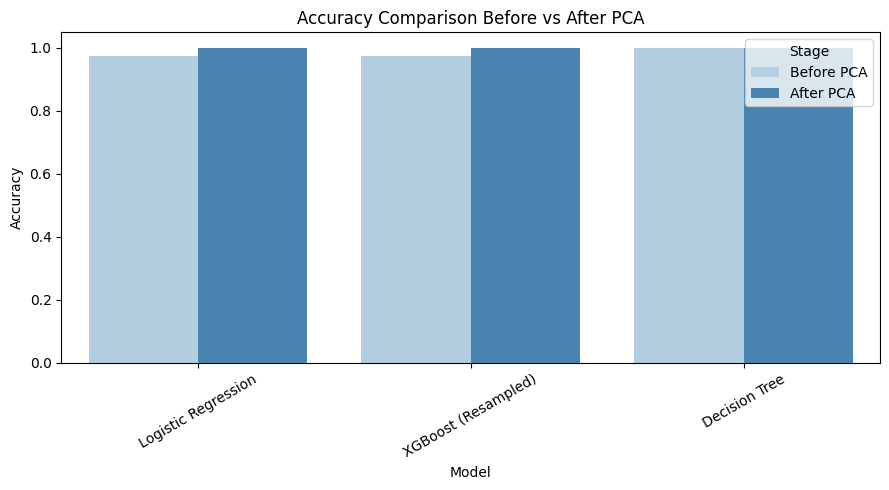

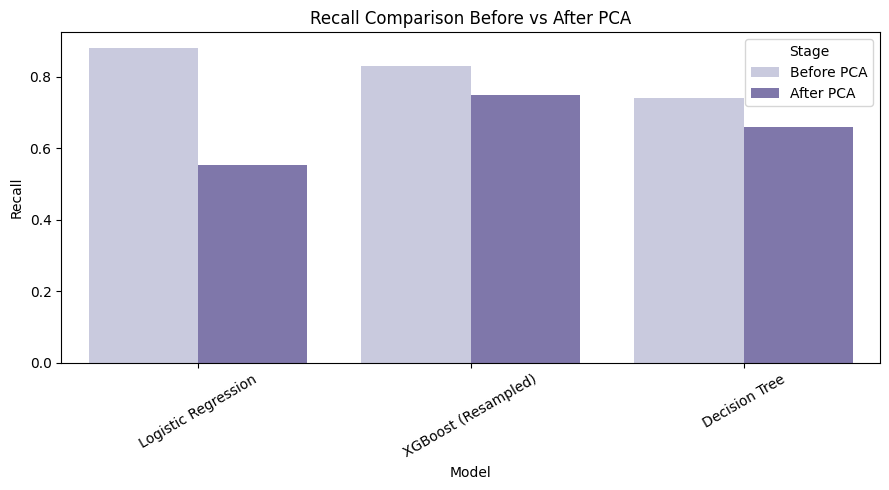

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# BEFORE PCA
# =========================
before_results = [
    {'Model': 'Logistic Regression', 'Accuracy': 0.9750816513545901, 'Precision': 0.0531, 'Recall': 0.8806, 'F1-score': 0.1001},
    {'Model': 'XGBoost (Resampled)', 'Accuracy': 0.9750816513545901, 'Precision': 0.45, 'Recall': 0.83, 'F1-score': 0.58},
    {'Model': 'Decision Tree', 'Accuracy': 0.9979205338471299, 'Precision': 0.41, 'Recall': 0.74, 'F1-score': 0.53},
]

before_df = pd.DataFrame(before_results)
before_df['Stage'] = 'Before PCA'

# =========================
# AFTER PCA
# =========================
after_results = [
    {'Model': 'Logistic Regression', 'Accuracy': 0.999177612255927, 'Precision': 0.8810, 'Recall': 0.5522, 'F1-score': 0.6789},
    {'Model': 'XGBoost (Resampled)', 'Accuracy': 0.999177612255927, 'Precision': 0.92, 'Recall': 0.75, 'F1-score': 0.82},
    {'Model': 'Decision Tree', 'Accuracy': 0.9992011090486148, 'Precision': 0.79, 'Recall': 0.66, 'F1-score': 0.72},
]

after_df = pd.DataFrame(after_results)
after_df['Stage'] = 'After PCA'

# =========================
# MERGE BOTH
# =========================
all_df = pd.concat([before_df, after_df])

# =========================
# PRINT TABLE
# =========================
print("\n📊 Full Comparison Table:\n")
print(all_df)

# =========================
# VISUALIZATION - ACCURACY
# =========================
plt.figure(figsize=(9,5))
sns.barplot(
    data=all_df,
    x='Model',
    y='Accuracy',
    hue='Stage',
    palette='Blues'
)

plt.title("Accuracy Comparison Before vs After PCA")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# =========================
# VISUALIZATION - RECALL
# =========================
plt.figure(figsize=(9,5))
sns.barplot(
    data=all_df,
    x='Model',
    y='Recall',
    hue='Stage',
    palette='Purples'
)

plt.title("Recall Comparison Before vs After PCA")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()